# Help Desk Ticket SLA and Volume Forecasting

This capstone uses `data/raw/issues.csv` for two integrated workstreams: **(1) retrospective comparison of elapsed resolution time with project-configured SLA references by recorded priority; and (2) separate 7- and 30-day daily Ticket-volume forecasting experiments for capacity-planning research.** The 30-day forecast is a daily path, not one monthly total. The primary analysis includes `issue_type == Ticket` and creation dates on/after 2016-01-01 UTC, matching the period described in the accompanying source documentation.

**Important source caveat:** the CSV contains creation dates before 2016 despite the documentation's stated range. Those records are profiled but excluded from the primary scope. Dates without scoped Ticket rows are treated as zero arrivals in the forecasting series under an explicit completeness assumption that has not been independently verified. The source ends in March 2023 and cannot establish current operational performance.

The configured SLA references are project assumptions: Blocker/Highest → Critical (4h), High (8h), Medium (24h), Low/Lowest → Low (24h); `unknown` is excluded. The measured duration is calendar wall-clock time between creation and recorded resolution—not a verified business-hours SLA clock. Results are retrospective, not contractual compliance or a live warning model.

**Shared retrospective result across this notebook sequence:** among 16,735 eligible completed Tickets, 3,333 (19.9%) met the configured reference. By mapped priority: Critical 524/2,124 (24.7%); High 576/3,146 (18.3%); Medium 2,161/11,161 (19.4%); Low 72/304 (23.7%). Eligibility requires exact Ticket type, documented 2016+ scope, `Done`, known mapped priority, and valid nonnegative elapsed duration. Notebook 02 shows the detailed comparison; these same counts and caveats are the project-wide retrospective baseline.


# 02 | Ticket EDA, feature engineering, selection and PCA

This project predicts a numeric daily ticket count, so it is a time-series regression task, not a classification task. Accuracy, precision, recall and sensitivity require class labels and are not appropriate forecast metrics here; Notebook 03 evaluates MAE, RMSE, WAPE, sMAPE and interval coverage instead. The SLA attainment labels are retrospective descriptive outcomes, not predictions from a trained classifier.

This notebook examines category and numeric distributions, weekly/monthly patterns, resolution-time relationships and numeric associations. Forecast features are engineered from prior daily counts and calendar cycles. Mutual-information feature selection and PCA are fitted on training data only; model-based importance and SHAP for the XGBoost challenger are in Notebook 04. Clustering tendency and t-SNE/UMAP are not applied because this project has no unsupervised segmentation objective; PCA is used for the supervised Ridge comparison.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display
from src.issues_capstone import run_eda
result = run_eda()
print({key: value for key, value in result.items() if key != 'issue_types'})
display(result['issue_types'])


{'selected_features': ['lag_5', 'lag_7', 'lag_9', 'lag_12', 'lag_14', 'lag_19', 'lag_21', 'lag_28', 'weekday_sin', 'weekday_cos'], 'pca_components': 26, 'validation_start': Timestamp('2021-03-15 00:00:00+0000', tz='UTC'), 'ticket_rows': 27348}


,issue_type,rows,projects
13,Ticket,45275,346
7,Service,5300,257
11,Subtask,4746,173
9,Story,4538,28
4,HD Service,1686,134
12,Task,1540,2
14,Vacation,856,23
5,Project,842,92
10,Sub-task,544,9
3,Epic,403,24


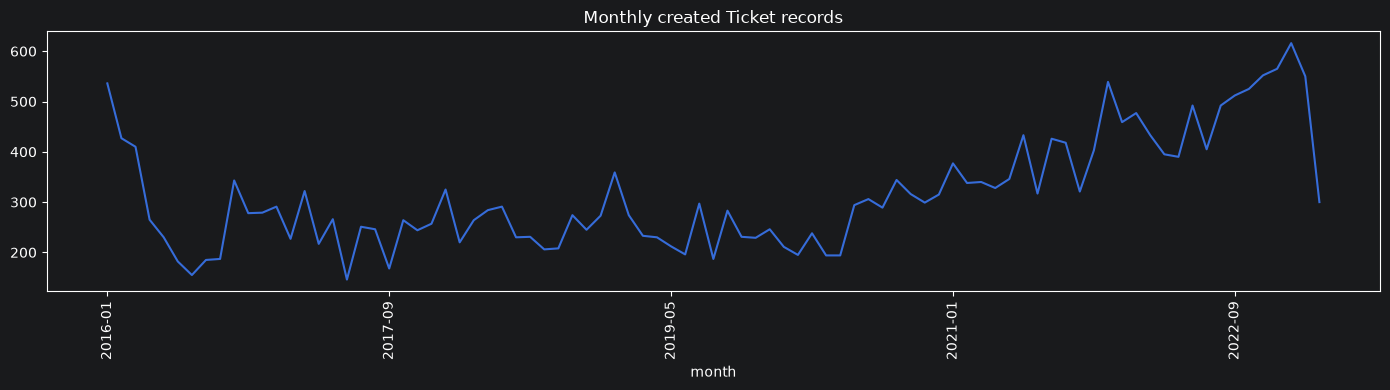

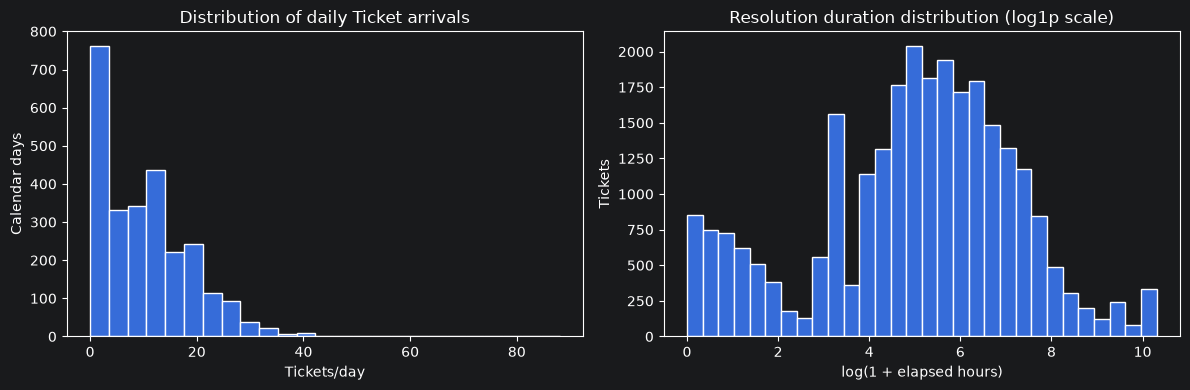

Daily arrival distribution:


,count,mean,std,min,25%,50%,75%,90%,95%,max
tickets,2628.0,10.406393,8.902166,0.0,2.0,10.0,16.0,22.0,26.0,88.0


Recorded priorities:


,tickets
priority,
Medium,12112
unknown,9145
High,3451
Highest,1707
Blocker,568
Low,344
Lowest,21


,created_weekday,tickets,sla_eligible
0,Friday,416,284
1,Monday,5598,3760
2,Saturday,488,376
3,Sunday,5899,3806
4,Thursday,4639,3102
5,Tuesday,5296,3532
6,Wednesday,5012,3343


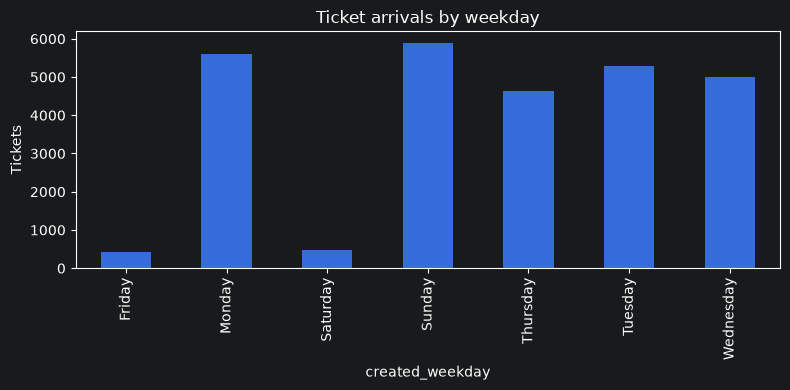

Retrospective SLA-reference attainment by mapped priority


,Mapped priority,Configured reference (hours),Eligible completed tickets,Met reference,Exceeded reference,Met (%),Median elapsed hours,90th percentile elapsed hours
0,Critical,4.0,2124,524,1600,24.67,73.49,958.54
1,High,8.0,3146,576,2570,18.31,112.62,1172.86
3,Medium,24.0,11161,2161,9000,19.36,171.55,1357.65
2,Low,24.0,304,72,232,23.68,171.00,2116.56


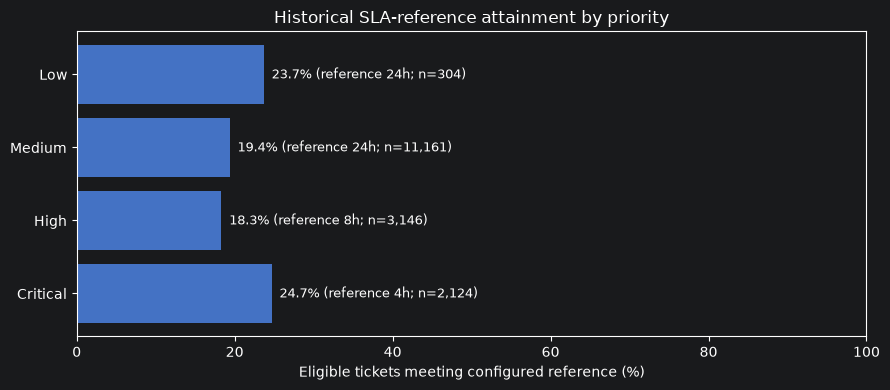

,mapped_priority,assessed,median_elapsed_hours,p90_elapsed_hours,p95_elapsed_hours
0,Critical,2124,73.493472,958.538556,1465.956750
1,High,3146,112.619444,1172.855972,2181.999375
2,Low,304,170.996944,2116.562694,4786.611833
3,Medium,11161,171.545764,1357.650833,2307.073889


,issue_comments_count,issue_contr_count,processing_steps,wf_total_time,elapsed_wall_clock_hours
issue_comments_count,1.00,0.31,0.55,0.38,0.37
issue_contr_count,0.31,1.00,0.40,-0.05,-0.06
processing_steps,0.55,0.40,1.00,0.21,0.19
wf_total_time,0.38,-0.05,0.21,1.00,1.00
elapsed_wall_clock_hours,0.37,-0.06,0.19,1.00,1.00


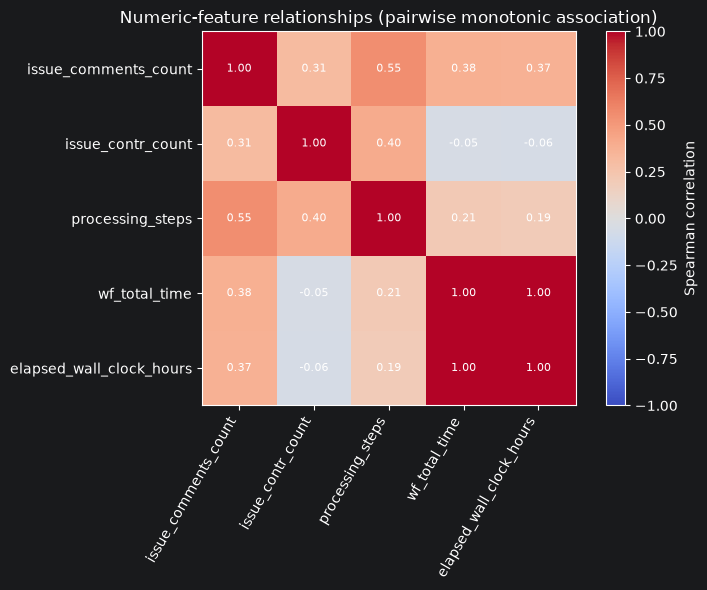

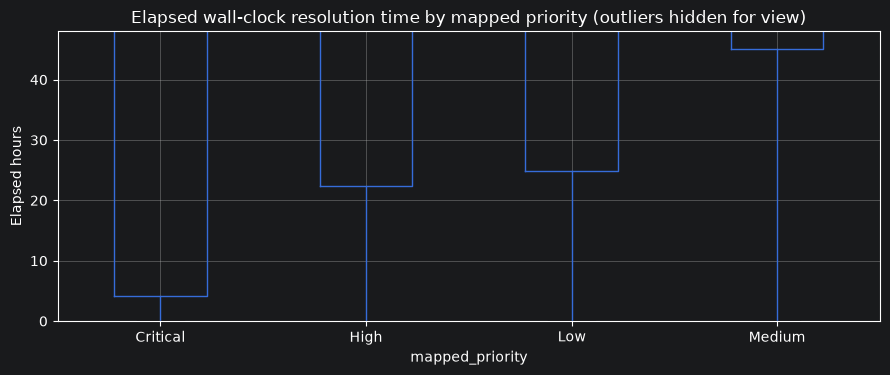

The boxplot is limited to 0–48 hours for readability; the duration distribution above includes the full observed range.


,feature,mutual_information_score,selected_in_training_only
0,weekday_sin,0.478927,True
1,lag_7,0.422904,True
2,lag_28,0.416905,True
3,lag_21,0.397213,True
4,lag_14,0.387822,True
5,weekday_cos,0.146608,True
6,lag_9,0.117981,True
7,lag_12,0.103264,True
8,lag_19,0.103018,True
9,lag_5,0.100121,True


,training_rows,original_features,selected_features,pca_components_for_target_variance,explained_variance_ratio,fit_cutoff,purpose
0,1870,34,10,26,0.953711,2021-03-15T00:00:00+00:00,training-only exploratory reduction of past-co...


In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.issues_capstone import PROJECT_REPORTS, REPORTS
from src.issues_capstone import source_and_ticket_data
_, ticket_data = source_and_ticket_data()
monthly = pd.read_csv(PROJECT_REPORTS / "monthly_ticket_volume.csv")
monthly.plot(x="month", y="tickets", figsize=(14, 4), legend=False, title="Monthly created Ticket records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
daily = pd.read_csv(REPORTS / "daily_ticket_counts.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(daily["tickets"], bins=25, edgecolor="white")
axes[0].set(title="Distribution of daily Ticket arrivals", xlabel="Tickets/day", ylabel="Calendar days")
axes[1].hist(np.log1p(ticket_data["elapsed_wall_clock_hours"].dropna()), bins=30, edgecolor="white")
axes[1].set(title="Resolution duration distribution (log1p scale)", xlabel="log(1 + elapsed hours)", ylabel="Tickets")
plt.tight_layout()
plt.show()
print("Daily arrival distribution:")
display(daily["tickets"].describe(percentiles=[.25, .5, .75, .9, .95]).to_frame().T)
print("Recorded priorities:")
display(ticket_data["issue_priority"].value_counts(dropna=False).rename_axis("priority").to_frame("tickets"))
weekday = pd.read_csv(PROJECT_REPORTS / "tickets_by_weekday.csv")
display(weekday)
weekday.plot(x="created_weekday", y="tickets", kind="bar", legend=False, figsize=(8, 4),
             title="Ticket arrivals by weekday")
plt.ylabel("Tickets")
plt.tight_layout()
plt.show()
sla = pd.read_csv(PROJECT_REPORTS / "sla_attainment_by_priority.csv")
sla = sla.loc[~sla["priority"].eq("Overall")].copy()
priority_order = ["Critical", "High", "Medium", "Low"]
sla["priority"] = pd.Categorical(sla["priority"], categories=priority_order, ordered=True)
sla = sla.sort_values("priority")
sla["reference_breached"] = sla["assessed_tickets"] - sla["reference_met"]
sla_table = sla[[
    "priority", "reference_hours", "assessed_tickets", "reference_met",
    "reference_breached", "reference_met_pct", "median_elapsed_hours", "p90_elapsed_hours",
]].rename(columns={
    "priority": "Mapped priority",
    "reference_hours": "Configured reference (hours)",
    "assessed_tickets": "Eligible completed tickets",
    "reference_met": "Met reference",
    "reference_breached": "Exceeded reference",
    "reference_met_pct": "Met (%)",
    "median_elapsed_hours": "Median elapsed hours",
    "p90_elapsed_hours": "90th percentile elapsed hours",
})
print("Retrospective SLA-reference attainment by mapped priority")
display(sla_table.round(2))
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    sla["priority"].astype(str),
    sla["reference_met_pct"],
    color="#4472C4",
)
ax.set_xlim(0, 100)
ax.set_xlabel("Eligible tickets meeting configured reference (%)")
ax.set_title("Historical SLA-reference attainment by priority")
for bar, row in zip(bars, sla.itertuples()):
    ax.text(
        min(row.reference_met_pct + 1, 84),
        bar.get_y() + bar.get_height() / 2,
        f"{row.reference_met_pct:.1f}% (reference {row.reference_hours:.0f}h; n={row.assessed_tickets:,})",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()
duration = pd.read_csv(PROJECT_REPORTS / "resolution_duration_by_priority.csv")
display(duration)
correlation = pd.read_csv(PROJECT_REPORTS / "ticket_numeric_spearman_correlation.csv", index_col=0)
display(correlation.round(2))
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=60, ha="right")
ax.set_yticks(range(len(correlation.index)), correlation.index)
for row in range(len(correlation.index)):
    for col in range(len(correlation.columns)):
        ax.text(col, row, f"{correlation.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Spearman correlation")
ax.set_title("Numeric-feature relationships (pairwise monotonic association)")
plt.tight_layout()
plt.show()
resolved = ticket_data.loc[
    ticket_data["issue_resolution"].eq("Done")
    & ticket_data["mapped_priority"].notna()
    & ticket_data["elapsed_wall_clock_hours"].notna()
]
resolved.boxplot(column="elapsed_wall_clock_hours", by="mapped_priority", showfliers=False, figsize=(9, 4))
plt.ylim(0, 48)
plt.title("Elapsed wall-clock resolution time by mapped priority (outliers hidden for view)")
plt.suptitle("")
plt.ylabel("Elapsed hours")
plt.tight_layout()
plt.show()
print("The boxplot is limited to 0–48 hours for readability; the duration distribution above includes the full observed range.")
display(pd.read_csv(PROJECT_REPORTS / "forecast_training_feature_selection.csv").head(15))
display(pd.read_csv(PROJECT_REPORTS / "forecast_pca_diagnostics.csv"))


## Retrospective SLA-reference measurement by priority

The table and chart above compare observed elapsed resolution time with the configured reference separately for each mapped priority. The cohort is limited to exact `Ticket` records created in the documented 2016+ scope that are marked `Done`, have a known mapped priority, and have a valid nonnegative creation-to-resolution duration. `Met (%)` is the count within that priority whose elapsed UTC wall-clock duration is at or below its configured reference, divided by all eligible tickets in that priority; the remainder exceeded the reference. `n` is the eligible denominator. Median and 90th-percentile elapsed times show the full duration distribution alongside the binary reference comparison. These are retrospective reference rates—not model precision/recall and not confirmed contractual SLA compliance, because the configured thresholds and business-hours/pause rules have not been verified.

## Feature-engineering, selection and dimensionality reduction

Creation timestamps are parsed as UTC, the documented period is enforced, and the primary cohort is restricted to exact `Ticket` records. Missing calendar dates are zero-filled only under the unverified coverage assumption. Each supervised row predicts today's count using only information available before that date: 28 daily lags, 7/28-day rolling means, sine/cosine weekday encodings and sine/cosine annual-cycle encodings. Rolling means summarize recent level; cyclical encodings represent recurring calendar patterns without an artificial boundary between Sunday/Monday or year-end/year-start.

**Feature selection:** mutual-information `SelectKBest` ranks candidate predictors by their estimated dependence with next-day volume; the configured top 10 features are retained for the Ridge comparison. This is a filter method, not a causal ranking. **Dimensionality reduction:** standardized training features are transformed by PCA, retaining enough components for 95% explained variance (26 of 34 components in this run); the MI-selection/PCA steps are refitted within each rolling origin for Ridge evaluation. PCA is for the supervised forecast comparison, not a visual cluster map. Clustering tendency and t-SNE/UMAP are intentionally omitted because there is no unsupervised clustering question or validated cluster use case. See Notebook 04 for XGBoost model-based importance and validation-only SHAP; those explain the challenger model, not the selected ETS forecast.

### Binning: duration bands aligned to SLA references

A domain-derived categorical feature is built by binning each resolved ticket's elapsed wall-clock duration into bands aligned to the configured priority reference hours (4h / 8h / 24h / beyond all references). This is a descriptive EDA cut, not a forecasting model input: the daily-count forecast models in Notebook 03 use only the lag/rolling/cyclical features listed above, refit on information available before each prediction date.

,tickets
duration_band,
<=4h (Critical band),2403
4-8h (High band),458
8-24h (Medium/Low band),985
>24h (beyond all references),12889


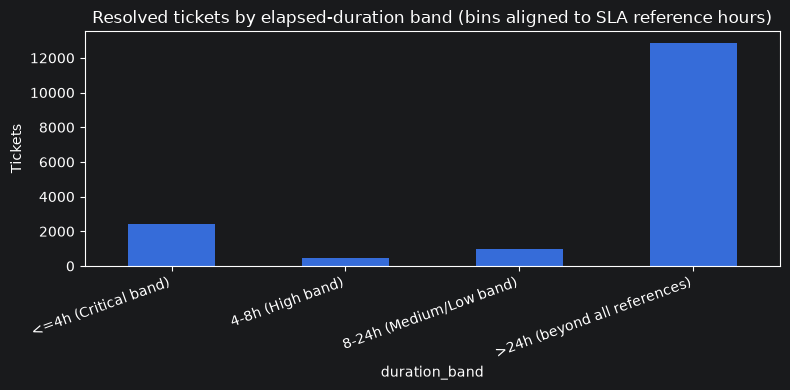

Binning is descriptive only here; it is not fed into the daily-count forecast models.


In [3]:
duration_bins = [-0.01, 4, 8, 24, float("inf")]
duration_labels = ["<=4h (Critical band)", "4-8h (High band)", "8-24h (Medium/Low band)", ">24h (beyond all references)"]
resolved_with_bins = resolved.assign(
    duration_band=pd.cut(resolved["elapsed_wall_clock_hours"], bins=duration_bins, labels=duration_labels)
)
band_counts = resolved_with_bins["duration_band"].value_counts().reindex(duration_labels)
display(band_counts.to_frame("tickets"))
band_counts.plot(kind="bar", figsize=(8, 4), legend=False,
                  title="Resolved tickets by elapsed-duration band (bins aligned to SLA reference hours)")
plt.ylabel("Tickets")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
print("Binning is descriptive only here; it is not fed into the daily-count forecast models.")

### In summary

This notebook explores the ticket data visually and numerically, by category, by week, by month, and builds the ingredients the forecasting models will use later, things like how many tickets came in over the past few weeks and what day of the week or time of year it is. It also picks the most useful of those ingredients using a statistical selection method and compresses them with PCA, a technique that reduces many related signals into fewer, cleaner ones. None of this is classification; it is preparation for predicting a number, the daily ticket count, so there is no accuracy or precision score here. That comes in the next notebook.